# GRASP 贪心随机自适应搜索

## 本 Notebook 的教学目标

1. 在经典 TSP 场景下理解该算法的工作机制。
2. 完成一个从零实现版本，而不是只调用现成库。
3. 通过路径图、收敛曲线、统计结果观察算法行为。
4. 为下个月授课准备可直接展示的实验材料。

## 为什么选 TSP

GRASP 用 TSP 非常好讲，因为它天然分成两段：先构造一条“还不错”的路径，再用局部搜索把它继续改好。

TSP 的优点是：**结果是可视化路径，过程也是可视化路径**。因此它非常适合课堂讲解组合优化算法。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque

# 统一图表风格，保证不同 Notebook 的视觉体验一致。
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# 为了让路径图更直观，这里统一生成二维城市坐标。

def make_cities(n_cities=20, seed=7):
    rng = np.random.default_rng(seed)
    return rng.uniform(0, 100, size=(n_cities, 2))


def pairwise_distances(cities):
    diff = cities[:, None, :] - cities[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))


def route_length(route, distance_matrix):
    rolled = np.roll(route, -1)
    return float(distance_matrix[route, rolled].sum())


def plot_route(cities, route, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    ordered = cities[route]
    closed = np.vstack([ordered, ordered[0]])
    ax.plot(closed[:, 0], closed[:, 1], '-o', color='#1f77b4', lw=2, ms=6)
    for idx, (x, y) in enumerate(cities):
        ax.text(x + 1, y + 1, str(idx), fontsize=10)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    return ax


def two_opt_swap(route, i, j):
    new_route = route.copy()
    new_route[i:j] = route[i:j][::-1]
    return new_route


def random_route(rng, n_cities):
    return rng.permutation(n_cities)


def summarize_runs(scores):
    return pd.Series({
        'best': float(np.min(scores)),
        'mean': float(np.mean(scores)),
        'worst': float(np.max(scores)),
        'std': float(np.std(scores)),
    })


# 固定城市坐标，保证不同算法 Notebook 之间有可比性。
cities = make_cities(n_cities=20, seed=11)
distance_matrix = pairwise_distances(cities)

## 算法直觉

核心思想：先用带随机性的贪心策略构造解，避免每次都得到同一条路径；再用局部搜索进行精修。多次重复后保留最优结果。

在讲课时，可以把这个算法与“纯贪心”或“纯随机搜索”对照起来讲，学生更容易抓住重点。

In [2]:
def greedy_randomized_construction(distance_matrix, rng, alpha=0.3):
    n_cities = len(distance_matrix)
    start = rng.integers(0, n_cities)
    route = [start]
    unvisited = set(range(n_cities)) - {start}

    while unvisited:
        current = route[-1]
        candidates = sorted(list(unvisited), key=lambda city: distance_matrix[current, city])
        distances = np.array([distance_matrix[current, city] for city in candidates])

        # RCL 的长度由 alpha 控制：alpha 越大，随机性越强。
        threshold = distances.min() + alpha * (distances.max() - distances.min())
        rcl = [city for city in candidates if distance_matrix[current, city] <= threshold]
        next_city = rng.choice(rcl)
        route.append(int(next_city))
        unvisited.remove(int(next_city))

    return np.array(route, dtype=int)


def local_search_2opt(route, distance_matrix, max_passes=30):
    route = route.copy()
    best_length = route_length(route, distance_matrix)

    for _ in range(max_passes):
        improved = False
        for i in range(1, len(route) - 2):
            for j in range(i + 1, len(route)):
                candidate = two_opt_swap(route, i, j)
                candidate_length = route_length(candidate, distance_matrix)
                if candidate_length < best_length:
                    route = candidate
                    best_length = candidate_length
                    improved = True
        if not improved:
            break
    return route, float(best_length)


def grasp(distance_matrix, n_iterations=60, alpha=0.3, seed=0):
    rng = np.random.default_rng(seed)
    best_route = None
    best_length = np.inf
    history = []
    snapshots = []

    for iteration in range(1, n_iterations + 1):
        constructed = greedy_randomized_construction(distance_matrix, rng, alpha=alpha)
        constructed_length = route_length(constructed, distance_matrix)
        improved_route, improved_length = local_search_2opt(constructed, distance_matrix)

        history.append((constructed_length, improved_length))
        if improved_length < best_length:
            best_route = improved_route.copy()
            best_length = improved_length
            snapshots.append((iteration, constructed.copy(), improved_route.copy()))

    return {
        'best_route': best_route,
        'best_length': float(best_length),
        'history': np.array(history),
        'snapshots': snapshots[:5],
    }

## 单次实验演示

下面先做一次完整实验。建议课堂上先关注：

1. 初始路径和最终路径差别有多大。
2. 收敛过程中是否存在明显跳跃。
3. 算法是否会在早期快速改进、后期缓慢收敛。

best route length: 377.111


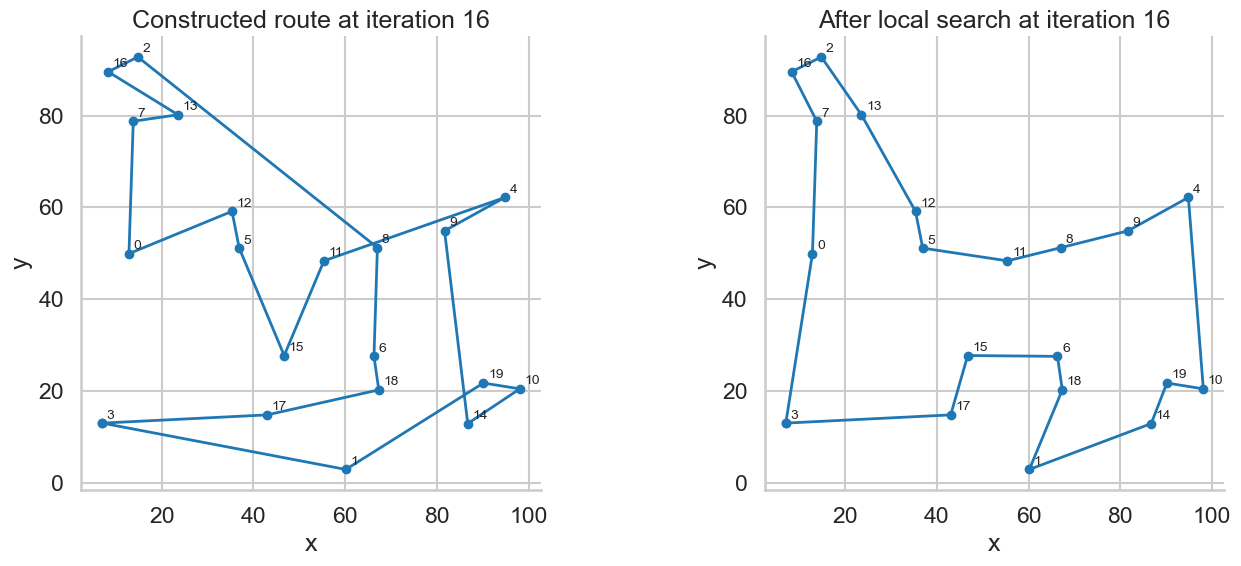

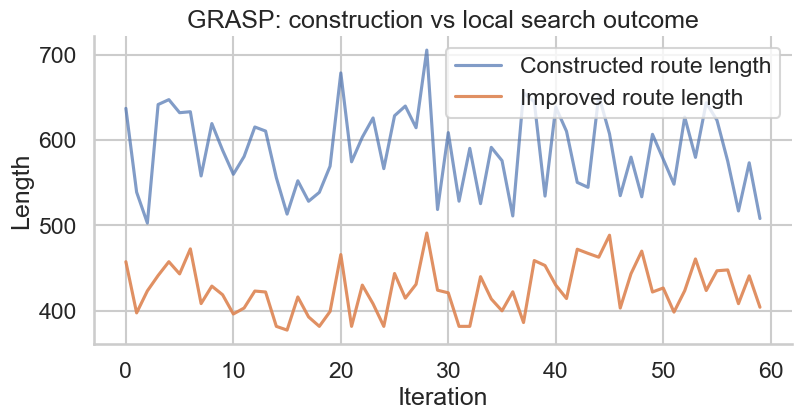

<Figure size 700x700 with 0 Axes>

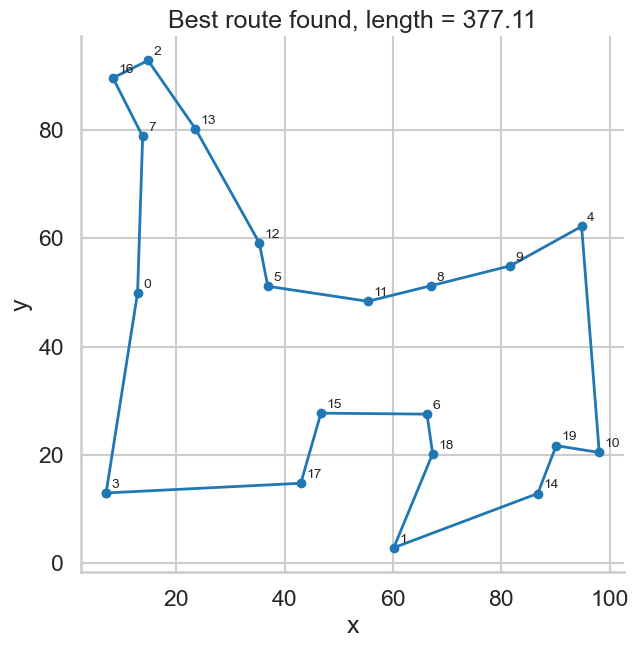

In [3]:
grasp_result = grasp(distance_matrix, seed=1)
print('best route length:', round(grasp_result['best_length'], 3))

if grasp_result['snapshots']:
    iteration, constructed_route, improved_route = grasp_result['snapshots'][-1]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    plot_route(cities, constructed_route, f'Constructed route at iteration {iteration}', ax=axes[0])
    plot_route(cities, improved_route, f'After local search at iteration {iteration}', ax=axes[1])
    plt.tight_layout()
    plt.show()

history_df = pd.DataFrame(grasp_result['history'], columns=['constructed_length', 'improved_length'])
plt.figure(figsize=(9, 4))
plt.plot(history_df['constructed_length'], label='Constructed route length', alpha=0.7)
plt.plot(history_df['improved_length'], label='Improved route length', alpha=0.9)
plt.title('GRASP: construction vs local search outcome')
plt.xlabel('Iteration')
plt.ylabel('Length')
plt.legend()
plt.show()

plt.figure(figsize=(7, 7))
plot_route(cities, grasp_result['best_route'], f'Best route found, length = {grasp_result["best_length"]:.2f}')
plt.show()

## 多次运行与参数分析

组合优化算法往往带有随机性，因此只看一次结果不够。这里用多次实验和参数敏感性分析来说明算法的稳定性与可调节性。

,GRASP statistics
best,377.110676
mean,378.203445
worst,381.481754
std,1.892733


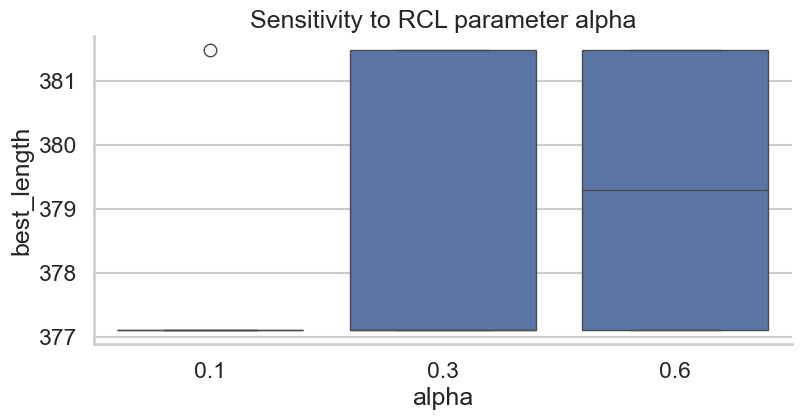

In [4]:
run_scores = [grasp(distance_matrix, seed=seed)['best_length'] for seed in range(20)]
display(summarize_runs(run_scores).to_frame(name='GRASP statistics'))

alpha_values = [0.1, 0.3, 0.6]
records = []
for alpha in alpha_values:
    for seed in range(10):
        best_length = grasp(distance_matrix, alpha=alpha, seed=seed)['best_length']
        records.append({'alpha': alpha, 'best_length': best_length})

param_df = pd.DataFrame(records)
plt.figure(figsize=(9, 4))
sns.boxplot(data=param_df, x='alpha', y='best_length')
plt.title('Sensitivity to RCL parameter alpha')
plt.show()

## 课堂总结

讲这一类 TSP 实验时，可以让学生反复回答三个问题：

1. 新路径是怎样产生的。
2. 更差的路径何时会被接受，或为什么永远不被接受。
3. 算法如何在“探索新结构”和“保留好结构”之间权衡。